In [5]:
pip install pandas numpy matplotlib seaborn scikit-learn ta

In [31]:
# Import Required Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Technical indicators
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.metrics import ConfusionMatrixDisplay

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Set display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", "{:.4f}".format)

# Set visualization style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("All required libraries have been imported successfully.")

All required libraries have been imported successfully.


In [35]:
# Load the Historical Stock Dataset

# Load the CSV dataset
df = pd.read_csv("aapl_us_d.csv")      

# Display the first five records
print("First Five Rows:")
display(df.head())

# Display the last five records
print("\nLast Five Rows:")
display(df.tail())

# Verify dataset dimensions
print("\nDataset Dimensions")
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Check data types
print("\nData Types:")
display(df.dtypes)

# Display dataset information
print("\nDataset Information:")
df.info()

First Five Rows:


,Date,Open,High,Low,Close,Volume
0,2020-01-02,71.4084,72.4606,71.1545,72.4006,140681710
1,2020-01-03,71.6304,72.4567,71.4724,71.6990,151973851
2,2020-01-06,70.8160,72.3055,70.5707,72.2661,122979354
3,2020-01-07,72.2759,72.5340,71.7108,71.9297,115649091
4,2020-01-08,71.6322,73.3858,71.6304,73.0857,137276166



Last Five Rows:


,Date,Open,High,Low,Close,Volume
1657,2026-08-07,311.4500,314.8100,310.7400,313.3300,34437191
1658,2026-08-10,306.8300,308.2600,304.6100,308.2600,44812503
1659,2026-08-11,307.7500,309.9700,302.7900,304.9100,37476746
1660,2026-08-12,305.1000,305.6600,300.5700,302.2500,41657768
1661,2026-08-13,304.2100,306.0000,302.0500,305.2600,40349289



Dataset Dimensions
Number of Rows    : 1662
Number of Columns : 6

Column Names:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

Data Types:


Date       object
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1662 entries, 0 to 1661
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1662 non-null   object 
 1   Open    1662 non-null   float64
 2   High    1662 non-null   float64
 3   Low     1662 non-null   float64
 4   Close   1662 non-null   float64
 5   Volume  1662 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 78.0+ KB


In [47]:
# Data Exploration

# Summary statistics
print("Summary Statistics:")
display(df.describe())

# Summary statistics including all columns
print("\nComplete Summary Statistics:")
display(df.describe(include='all'))

# Check missing values
print("\nMissing Values:")
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Values': missing_values.values,
    'Percentage (%)': (missing_values.values / len(df)) * 100
})

display(missing_df)

# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("\nDuplicate Records:")
print(f"Total Duplicate Rows: {duplicate_count}")

if duplicate_count > 0:
    display(df[df.duplicated()])
else:
    print("No duplicate records found.")

# Check unique values in each column
print("\nUnique Values in Each Column:")
unique_df = pd.DataFrame({
    'Column': df.columns,
    'Unique Values': [df[col].nunique() for col in df.columns]
})

display(unique_df)

Summary Statistics:


,Open,High,Low,Close,Volume
count,1662.0000,1662.0000,1662.0000,1662.0000,1662.0000
mean,175.4921,177.4754,173.6882,175.6697,83033925.3670
std,58.7265,59.2582,58.2870,58.8082,52236130.3118
min,55.1072,55.2104,51.3729,54.2145,17927333.0000
25%,135.8100,138.3380,134.0540,135.9610,49095666.2500
50%,168.8785,170.7025,167.7875,169.1550,67864795.0000
75%,219.0610,221.3160,216.1050,219.4015,98556671.7500
max,340.0300,344.5699,337.3501,340.0800,441679555.0000



Complete Summary Statistics:


,Date,Open,High,Low,Close,Volume
count,1662,1662.0000,1662.0000,1662.0000,1662.0000,1662.0000
unique,1662,NaN,NaN,NaN,NaN,NaN
top,2020-01-02,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,175.4921,177.4754,173.6882,175.6697,83033925.3670
std,NaN,58.7265,59.2582,58.2870,58.8082,52236130.3118
min,NaN,55.1072,55.2104,51.3729,54.2145,17927333.0000
25%,NaN,135.8100,138.3380,134.0540,135.9610,49095666.2500
50%,NaN,168.8785,170.7025,167.7875,169.1550,67864795.0000
75%,NaN,219.0610,221.3160,216.1050,219.4015,98556671.7500



Missing Values:


,Column,Missing Values,Percentage (%)
0,Date,0,0.0000
1,Open,0,0.0000
2,High,0,0.0000
3,Low,0,0.0000
4,Close,0,0.0000
5,Volume,0,0.0000



Duplicate Records:
Total Duplicate Rows: 0
No duplicate records found.

Unique Values in Each Column:


,Column,Unique Values
0,Date,1662
1,Open,1633
2,High,1633
3,Low,1633
4,Close,1625
5,Volume,1662


In [55]:
# Data Preprocessing

# Create a copy of the original dataset
df_clean = df.copy()

# Convert the Date column to datetime format
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%Y-%m-%d')

# Sort the dataset by Date in ascending order
df_clean = df_clean.sort_values(by='Date')

# Remove duplicate rows (if any)
duplicates_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()

# Check missing values
print("Missing Values Before Handling:")
print(df_clean.isnull().sum())

# Remove rows containing missing values
df_clean = df_clean.dropna()

# Reset the index
df_clean = df_clean.reset_index(drop=True)

# Verify preprocessing results
print("\nData Preprocessing Completed Successfully!")

print(f"\nDataset Shape: {df_clean.shape}")

print(f"\nDuplicate Rows Removed: {duplicates_before}")

print("\nRemaining Missing Values:")
print(df_clean.isnull().sum())

print("\nFirst Five Records After Preprocessing:")
display(df_clean.head())

print("\nDataset Information:")
df_clean.info()

Missing Values Before Handling:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Data Preprocessing Completed Successfully!

Dataset Shape: (1662, 6)

Duplicate Rows Removed: 0

Remaining Missing Values:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

First Five Records After Preprocessing:


,Date,Open,High,Low,Close,Volume
0,2020-01-02,71.4084,72.4606,71.1545,72.4006,140681710
1,2020-01-03,71.6304,72.4567,71.4724,71.6990,151973851
2,2020-01-06,70.8160,72.3055,70.5707,72.2661,122979354
3,2020-01-07,72.2759,72.5340,71.7108,71.9297,115649091
4,2020-01-08,71.6322,73.3858,71.6304,73.0857,137276166



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1662 entries, 0 to 1661
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1662 non-null   datetime64[ns]
 1   Open    1662 non-null   float64       
 2   High    1662 non-null   float64       
 3   Low     1662 non-null   float64       
 4   Close   1662 non-null   float64       
 5   Volume  1662 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 78.0 KB


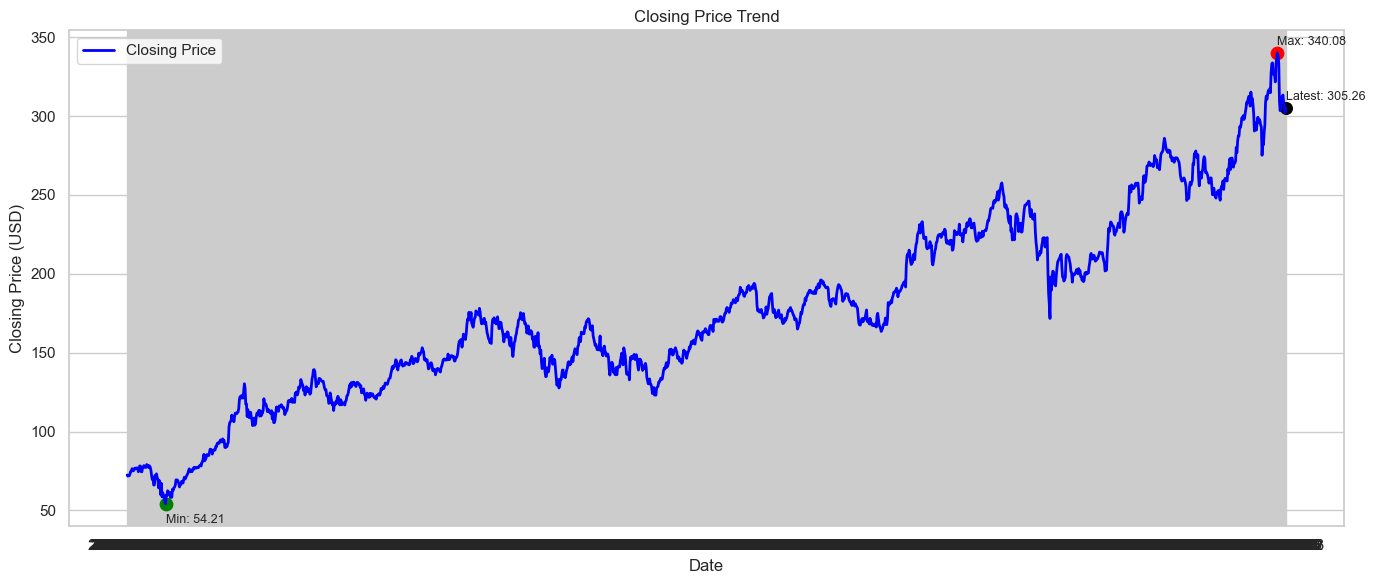

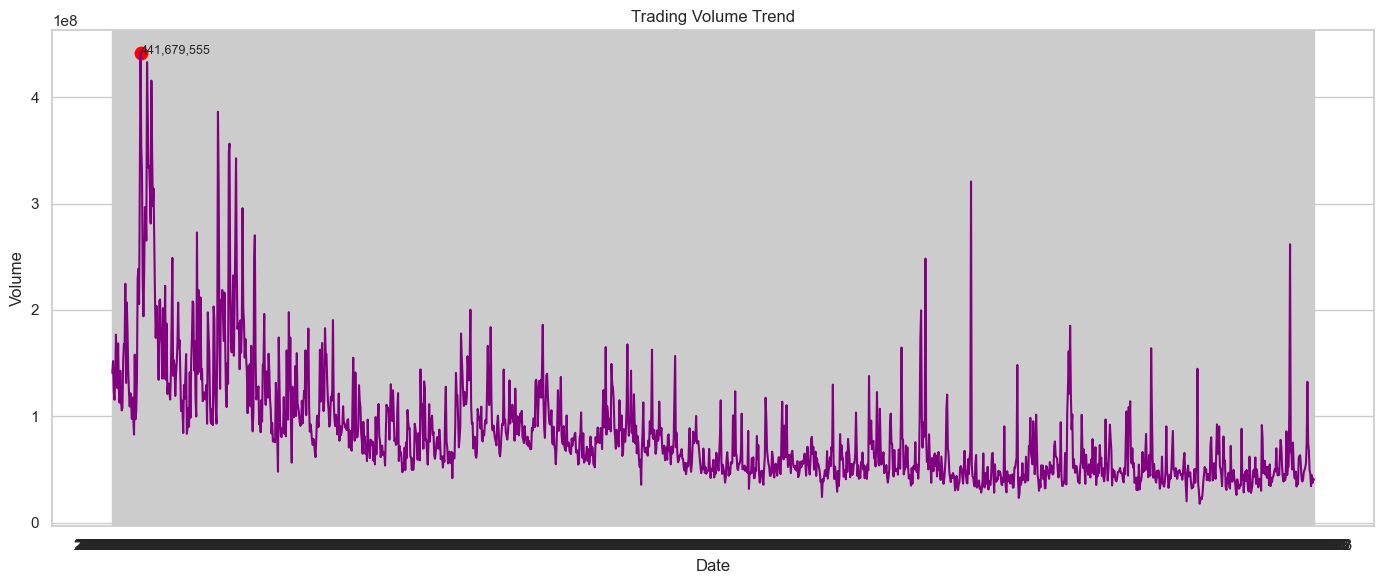

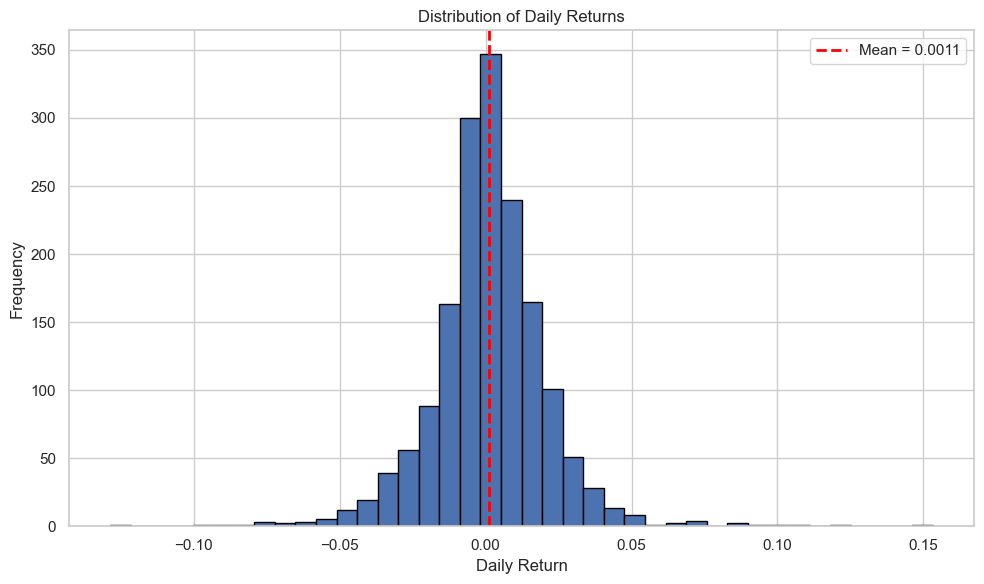

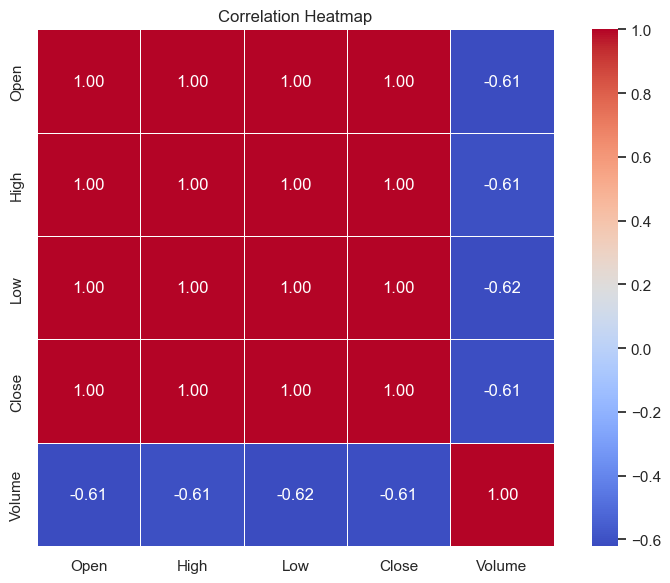

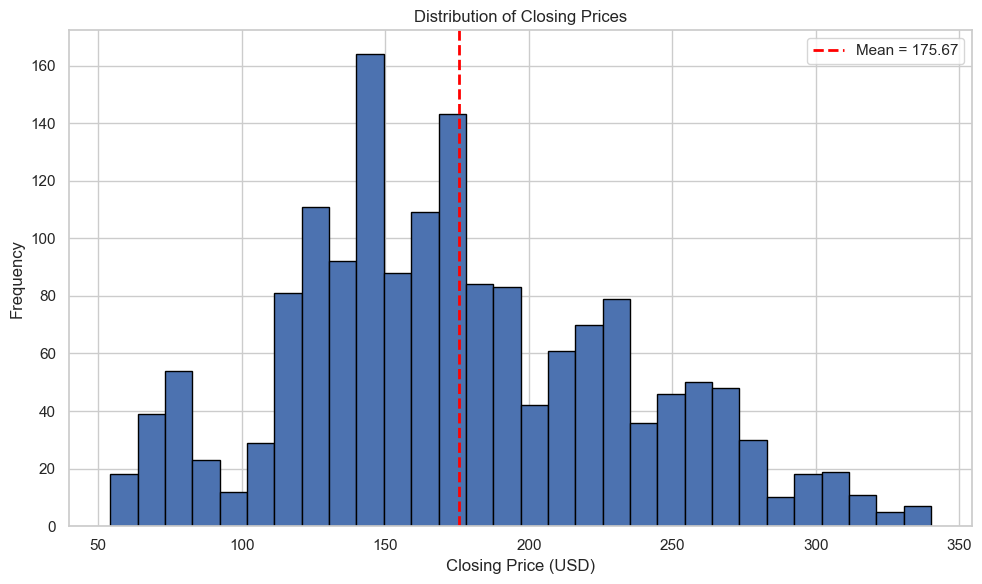

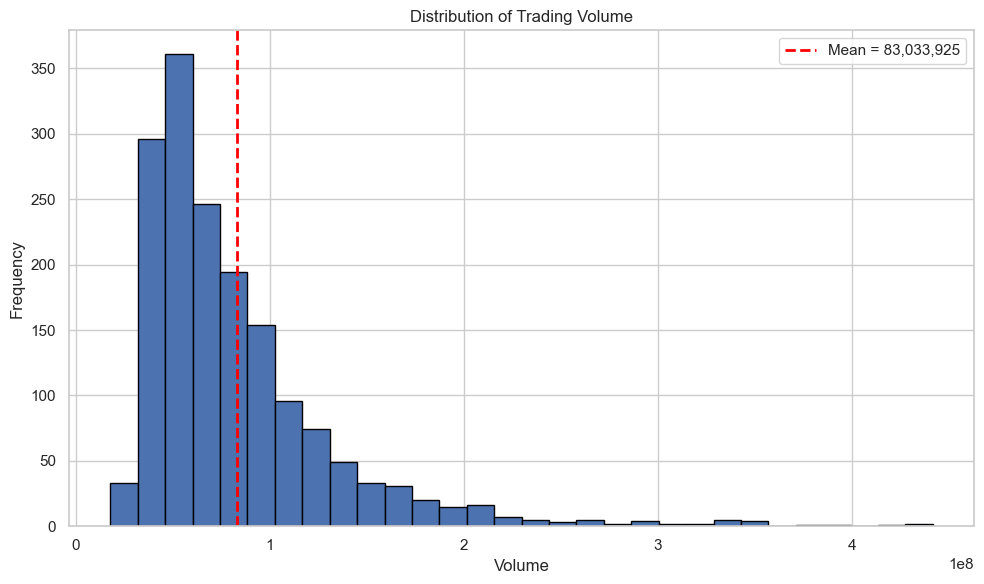

Exploratory Data Analysis completed successfully.


In [53]:
# Exploratory Data Analysis (EDA)

# Create a copy of the cleaned dataset
eda_df = df_clean.copy()

# Calculate Daily Returns
eda_df['Daily_Return'] = eda_df['Close'].pct_change()

# Closing Price Trend
plt.figure(figsize=(14,6))

plt.plot(
    eda_df['Date'],
    eda_df['Close'],
    color='blue',
    linewidth=2,
    label='Closing Price'
)

# Maximum value
max_idx = eda_df['Close'].idxmax()
plt.scatter(
    eda_df.loc[max_idx, 'Date'],
    eda_df.loc[max_idx, 'Close'],
    color='red',
    s=80
)
plt.text(
    eda_df.loc[max_idx, 'Date'],
    eda_df.loc[max_idx, 'Close']+5,
    f"Max: {eda_df.loc[max_idx,'Close']:.2f}",
    fontsize=9
)

# Minimum value
min_idx = eda_df['Close'].idxmin()
plt.scatter(
    eda_df.loc[min_idx,'Date'],
    eda_df.loc[min_idx,'Close'],
    color='green',
    s=80
)
plt.text(
    eda_df.loc[min_idx,'Date'],
    eda_df.loc[min_idx,'Close']-12,
    f"Min: {eda_df.loc[min_idx,'Close']:.2f}",
    fontsize=9
)

# Latest value
plt.scatter(
    eda_df.iloc[-1]['Date'],
    eda_df.iloc[-1]['Close'],
    color='black',
    s=70
)

plt.text(
    eda_df.iloc[-1]['Date'],
    eda_df.iloc[-1]['Close']+5,
    f"Latest: {eda_df.iloc[-1]['Close']:.2f}",
    fontsize=9
)

plt.title("Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Trading Volume Trend
plt.figure(figsize=(14,6))

plt.plot(
    eda_df['Date'],
    eda_df['Volume'],
    color='purple',
    linewidth=1.5
)

max_vol = eda_df['Volume'].idxmax()

plt.scatter(
    eda_df.loc[max_vol,'Date'],
    eda_df.loc[max_vol,'Volume'],
    color='red',
    s=80
)

plt.text(
    eda_df.loc[max_vol,'Date'],
    eda_df.loc[max_vol,'Volume'],
    f"{eda_df.loc[max_vol,'Volume']:,}",
    fontsize=9
)

plt.title("Trading Volume Trend")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.tight_layout()
plt.show()

# Daily Returns Distribution
plt.figure(figsize=(10,6))

plt.hist(
    eda_df['Daily_Return'].dropna(),
    bins=40,
    edgecolor='black'
)

mean_return = eda_df['Daily_Return'].mean()

plt.axvline(
    mean_return,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean = {mean_return:.4f}"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))

corr = eda_df[['Open','High','Low','Close','Volume']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Closing Price Distribution
plt.figure(figsize=(10,6))

plt.hist(
    eda_df['Close'],
    bins=30,
    edgecolor='black'
)

mean_close = eda_df['Close'].mean()

plt.axvline(
    mean_close,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean = {mean_close:.2f}"
)

plt.title("Distribution of Closing Prices")
plt.xlabel("Closing Price (USD)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Trading Volume Distribution
plt.figure(figsize=(10,6))

plt.hist(
    eda_df['Volume'],
    bins=30,
    edgecolor='black'
)

mean_volume = eda_df['Volume'].mean()

plt.axvline(
    mean_volume,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean = {mean_volume:,.0f}"
)

plt.title("Distribution of Trading Volume")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Exploratory Data Analysis completed successfully.")

In [57]:
# Technical Indicator Generation

# Create a copy of the cleaned dataset
features_df = df_clean.copy()

# Simple Moving Average (SMA)
features_df['SMA_10'] = SMAIndicator(
    close=features_df['Close'],
    window=10
).sma_indicator()

features_df['SMA_20'] = SMAIndicator(
    close=features_df['Close'],
    window=20
).sma_indicator()

# Exponential Moving Average (EMA)
features_df['EMA_10'] = EMAIndicator(
    close=features_df['Close'],
    window=10
).ema_indicator()

features_df['EMA_20'] = EMAIndicator(
    close=features_df['Close'],
    window=20
).ema_indicator()

# Relative Strength Index (RSI)
features_df['RSI'] = RSIIndicator(
    close=features_df['Close'],
    window=14
).rsi()

# MACD
macd = MACD(close=features_df['Close'])

features_df['MACD'] = macd.macd()
features_df['MACD_Signal'] = macd.macd_signal()
features_df['MACD_Histogram'] = macd.macd_diff()

# Bollinger Bands
bb = BollingerBands(
    close=features_df['Close'],
    window=20,
    window_dev=2
)

features_df['BB_Upper'] = bb.bollinger_hband()
features_df['BB_Middle'] = bb.bollinger_mavg()
features_df['BB_Lower'] = bb.bollinger_lband()
features_df['BB_Width'] = (
    features_df['BB_Upper'] -
    features_df['BB_Lower']
)

# Momentum
features_df['Momentum'] = (
    features_df['Close'] -
    features_df['Close'].shift(10)
)

# Daily Return
features_df['Daily_Return'] = (
    features_df['Close'].pct_change()
)

# Rolling Volatility
features_df['Rolling_Volatility'] = (
    features_df['Daily_Return']
    .rolling(window=20)
    .std()
)

# Display Technical Indicators
print("Technical Indicators Generated Successfully.\n")

print("Generated Features:")
print(features_df.columns.tolist())

print("\nFirst Five Rows:")
display(features_df.head())

print("\nLast Five Rows:")
display(features_df.tail())

print("\nMissing Values After Feature Engineering:")
display(features_df.isnull().sum())

# Remove Initial Missing Values
features_df = features_df.dropna().reset_index(drop=True)

print("\nDataset Shape After Removing Missing Values:")
print(features_df.shape)

print("\nRemaining Missing Values:")
display(features_df.isnull().sum())

print("\nFirst Five Records After Feature Engineering:")
display(features_df.head())

Technical Indicators Generated Successfully.

Generated Features:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'SMA_10', 'SMA_20', 'EMA_10', 'EMA_20', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'BB_Width', 'Momentum', 'Daily_Return', 'Rolling_Volatility']

First Five Rows:


,Date,Open,High,Low,Close,Volume,SMA_10,SMA_20,EMA_10,EMA_20,RSI,MACD,MACD_Signal,MACD_Histogram,BB_Upper,BB_Middle,BB_Lower,BB_Width,Momentum,Daily_Return,Rolling_Volatility
0,2020-01-02,71.4084,72.4606,71.1545,72.4006,140681710,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-03,71.6304,72.4567,71.4724,71.6990,151973851,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0097,NaN
2,2020-01-06,70.8160,72.3055,70.5707,72.2661,122979354,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0079,NaN
3,2020-01-07,72.2759,72.5340,71.7108,71.9297,115649091,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0047,NaN
4,2020-01-08,71.6322,73.3858,71.6304,73.0857,137276166,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0161,NaN



Last Five Rows:


,Date,Open,High,Low,Close,Volume,SMA_10,SMA_20,EMA_10,EMA_20,RSI,MACD,MACD_Signal,MACD_Histogram,BB_Upper,BB_Middle,BB_Lower,BB_Width,Momentum,Daily_Return,Rolling_Volatility
1657,2026-08-07,311.4500,314.8100,310.7400,313.3300,34437191,320.7060,323.4315,316.8078,317.8042,47.5837,0.8781,4.0588,-3.1807,345.4473,323.4315,301.4157,44.0316,-19.6900,0.0029,0.0236
1658,2026-08-10,306.8300,308.2600,304.6100,308.2600,44812503,317.8410,322.9790,315.2537,316.8953,44.1019,0.0721,3.2615,-3.1894,345.8355,322.9790,300.1225,45.7129,-28.6500,-0.0162,0.0238
1659,2026-08-11,307.7500,309.9700,302.7900,304.9100,37476746,314.3240,322.4815,313.3730,315.7538,41.9193,-0.8274,2.4437,-3.2711,346.4302,322.4815,298.5328,47.8975,-35.1700,-0.0109,0.0238
1660,2026-08-12,305.1000,305.6600,300.5700,302.2500,41657768,310.7300,321.2190,311.3506,314.4677,40.2174,-1.7349,1.6080,-3.3429,346.5960,321.2190,295.8420,50.7540,-35.9400,-0.0087,0.0218
1661,2026-08-13,304.2100,306.0000,302.0500,305.2600,40349289,307.9130,319.8190,310.2433,313.5908,43.0358,-2.1861,0.8492,-3.0352,345.4723,319.8190,294.1657,51.3066,-28.1700,0.0100,0.0215



Missing Values After Feature Engineering:


Date                   0
Open                   0
High                   0
Low                    0
Close                  0
                      ..
BB_Lower              19
BB_Width              19
Momentum              10
Daily_Return           1
Rolling_Volatility    20
Length: 21, dtype: int64


Dataset Shape After Removing Missing Values:
(1629, 21)

Remaining Missing Values:


Date                  0
Open                  0
High                  0
Low                   0
Close                 0
                     ..
BB_Lower              0
BB_Width              0
Momentum              0
Daily_Return          0
Rolling_Volatility    0
Length: 21, dtype: int64


First Five Records After Feature Engineering:


,Date,Open,High,Low,Close,Volume,SMA_10,SMA_20,EMA_10,EMA_20,RSI,MACD,MACD_Signal,MACD_Histogram,BB_Upper,BB_Middle,BB_Lower,BB_Width,Momentum,Daily_Return,Rolling_Volatility
0,2020-02-20,77.9555,78.4450,76.8879,77.3950,104051293,77.9389,77.1869,77.6760,77.1100,53.0517,0.8413,0.9478,-0.1065,79.7991,77.1869,74.5747,5.2244,-0.0893,-0.0102,0.0190
1,2020-02-21,76.9879,77.4265,75.0235,75.6406,134200895,77.6636,77.1214,77.3059,76.9701,46.1338,0.6241,0.8830,-0.2589,79.8184,77.1214,74.4245,5.3939,-2.7533,-0.0227,0.0197
2,2020-02-24,71.8274,73.4956,69.8848,72.0483,229895979,77.1356,76.8874,76.3500,76.5013,35.8308,0.1603,0.7385,-0.5782,80.3761,76.8874,73.3987,6.9774,-5.2801,-0.0475,0.0223
3,2020-02-25,72.7177,73.0994,69.1372,69.6062,238667948,76.3267,76.6440,75.1238,75.8447,30.7957,-0.3998,0.5108,-0.9106,81.2671,76.6440,72.0209,9.2462,-8.0883,-0.0339,0.0226
4,2020-02-26,69.2340,71.9786,69.2272,70.7118,205600585,75.6750,76.3505,74.3217,75.3558,35.2330,-0.7458,0.2595,-1.0053,81.6483,76.3505,71.0528,10.5955,-6.5174,0.0159,0.0219


In [59]:
# Feature Engineering

# Create a copy of the dataset
model_df = features_df.copy()

# Create Binary Target Variable
# 1 = Next day's closing price is higher
# 0 = Next day's closing price is lower or equal

model_df['Target'] = (
    model_df['Close'].shift(-1) > model_df['Close']
).astype(int)

# Remove the Last Row
model_df = model_df.iloc[:-1]

# Select Input Features
feature_columns = [

    'Open',
    'High',
    'Low',
    'Close',
    'Volume',

    'SMA_10',
    'SMA_20',

    'EMA_10',
    'EMA_20',

    'RSI',

    'MACD',
    'MACD_Signal',
    'MACD_Histogram',

    'BB_Upper',
    'BB_Middle',
    'BB_Lower',
    'BB_Width',

    'Momentum',

    'Daily_Return',

    'Rolling_Volatility'
]

X = model_df[feature_columns]
y = model_df['Target']

# Remove Unnecessary Columns
model_df = model_df.drop(columns=['Date'])

# Handle Remaining Missing Values
print("Missing Values Before Final Check:")
display(model_df.isnull().sum())

model_df = model_df.dropna().reset_index(drop=True)

X = model_df[feature_columns]
y = model_df['Target']

# Display Results
print("Feature Engineering Completed Successfully.\n")

print("Selected Input Features:")
print(feature_columns)

print("\nNumber of Input Features:")
print(len(feature_columns))

print("\nTarget Variable Distribution:")
target_summary = (
    y.replace({
        1: 'Increase',
        0: 'Decrease'
    })
    .value_counts()
    .rename_axis('Stock Movement')
    .reset_index(name='Count')
)

display(target_summary)

print("\nTarget Variable Percentage:")
display(
    (
        y.value_counts(normalize=True) * 100
    ).round(2).rename_axis('Class').reset_index(name='Percentage (%)')
)

print("\nFinal Dataset Shape:")
print(model_df.shape)

print("\nFeature Matrix Shape (X):")
print(X.shape)

print("\nTarget Vector Shape (y):")
print(y.shape)

print("\nFirst Five Records:")
display(model_df.head())

Missing Values Before Final Check:


Open                  0
High                  0
Low                   0
Close                 0
Volume                0
                     ..
BB_Width              0
Momentum              0
Daily_Return          0
Rolling_Volatility    0
Target                0
Length: 21, dtype: int64

Feature Engineering Completed Successfully.

Selected Input Features:
['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_10', 'SMA_20', 'EMA_10', 'EMA_20', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'BB_Width', 'Momentum', 'Daily_Return', 'Rolling_Volatility']

Number of Input Features:
20

Target Variable Distribution:


,Stock Movement,Count
0,Increase,865
1,Decrease,763



Target Variable Percentage:


,Class,Percentage (%)
0,1,53.1300
1,0,46.8700



Final Dataset Shape:
(1628, 21)

Feature Matrix Shape (X):
(1628, 20)

Target Vector Shape (y):
(1628,)

First Five Records:


,Open,High,Low,Close,Volume,SMA_10,SMA_20,EMA_10,EMA_20,RSI,MACD,MACD_Signal,MACD_Histogram,BB_Upper,BB_Middle,BB_Lower,BB_Width,Momentum,Daily_Return,Rolling_Volatility,Target
0,77.9555,78.4450,76.8879,77.3950,104051293,77.9389,77.1869,77.6760,77.1100,53.0517,0.8413,0.9478,-0.1065,79.7991,77.1869,74.5747,5.2244,-0.0893,-0.0102,0.0190,0
1,76.9879,77.4265,75.0235,75.6406,134200895,77.6636,77.1214,77.3059,76.9701,46.1338,0.6241,0.8830,-0.2589,79.8184,77.1214,74.4245,5.3939,-2.7533,-0.0227,0.0197,0
2,71.8274,73.4956,69.8848,72.0483,229895979,77.1356,76.8874,76.3500,76.5013,35.8308,0.1603,0.7385,-0.5782,80.3761,76.8874,73.3987,6.9774,-5.2801,-0.0475,0.0223,0
3,72.7177,73.0994,69.1372,69.6062,238667948,76.3267,76.6440,75.1238,75.8447,30.7957,-0.3998,0.5108,-0.9106,81.2671,76.6440,72.0209,9.2462,-8.0883,-0.0339,0.0226,1
4,69.2340,71.9786,69.2272,70.7118,205600585,75.6750,76.3505,74.3217,75.3558,35.2330,-0.7458,0.2595,-1.0053,81.6483,76.3505,71.0528,10.5955,-6.5174,0.0159,0.0219,0


In [61]:
# Feature Scaling

# Time-Based Train-Test Split (80% Train, 20% Test)

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Apply StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Display Results

print("Feature Scaling Completed Successfully.\n")

print("Training Set Shape:")
print(X_train.shape)

print("\nTesting Set Shape:")
print(X_test.shape)

print("\nScaled Training Set Shape:")
print(X_train_scaled.shape)

print("\nScaled Testing Set Shape:")
print(X_test_scaled.shape)

print("\nTraining Target Shape:")
print(y_train.shape)

print("\nTesting Target Shape:")
print(y_test.shape)

print("\nFirst Five Rows of Scaled Training Data:")
display(X_train_scaled.head())

Feature Scaling Completed Successfully.

Training Set Shape:
(1302, 20)

Testing Set Shape:
(326, 20)

Scaled Training Set Shape:
(1302, 20)

Scaled Testing Set Shape:
(326, 20)

Training Target Shape:
(1302,)

Testing Target Shape:
(326,)

First Five Rows of Scaled Training Data:


,Open,High,Low,Close,Volume,SMA_10,SMA_20,EMA_10,EMA_20,RSI,MACD,MACD_Signal,MACD_Histogram,BB_Upper,BB_Middle,BB_Lower,BB_Width,Momentum,Daily_Return,Rolling_Volatility
0,-1.8602,-1.8790,-1.8566,-1.8743,0.2645,-1.8511,-1.8552,-1.8603,-1.8635,-0.0658,0.0423,0.0753,-0.0864,-1.9342,-1.8552,-1.7535,-1.5717,-0.1126,-0.5391,0.0743
1,-1.8828,-1.9026,-1.9004,-1.9153,0.8178,-1.8575,-1.8567,-1.8690,-1.8668,-0.6274,-0.0300,0.0520,-0.2468,-1.9338,-1.8567,-1.7571,-1.5521,-0.4088,-1.1384,0.1471
2,-2.0034,-1.9939,-2.0212,-1.9991,2.5739,-1.8699,-1.8622,-1.8913,-1.8777,-1.4639,-0.1843,-0.0000,-0.5828,-1.9213,-1.8622,-1.7818,-1.3683,-0.6897,-2.3342,0.4325
3,-1.9826,-2.0031,-2.0388,-2.0562,2.7349,-1.8887,-1.8678,-1.9200,-1.8931,-1.8726,-0.3706,-0.0819,-0.9325,-1.9013,-1.8678,-1.8149,-1.1051,-1.0020,-1.6793,0.4655
4,-2.0641,-2.0292,-2.0367,-2.0303,2.1281,-1.9039,-1.8747,-1.9387,-1.9045,-1.5124,-0.4858,-0.1724,-1.0321,-1.8928,-1.8747,-1.8382,-0.9485,-0.8273,0.7187,0.3839


In [63]:
# Train-Test Split

print("Time-Based Train-Test Split Completed Successfully.\n")

# Display dataset sizes
print(f"Total Dataset Size : {len(X)} samples")
print(f"Training Set Size  : {len(X_train)} samples")
print(f"Testing Set Size   : {len(X_test)} samples")

# Display percentages
train_percentage = (len(X_train) / len(X)) * 100
test_percentage = (len(X_test) / len(X)) * 100

print(f"\nTraining Percentage : {train_percentage:.2f}%")
print(f"Testing Percentage  : {test_percentage:.2f}%")

# Display date ranges
train_start = features_df.iloc[:split_index]['Date'].min()
train_end = features_df.iloc[:split_index]['Date'].max()

test_start = features_df.iloc[split_index:split_index + len(X_test)]['Date'].min()
test_end = features_df.iloc[split_index:split_index + len(X_test)]['Date'].max()

print("\nTraining Period:")
print(f"{train_start.date()}  to  {train_end.date()}")

print("\nTesting Period:")
print(f"{test_start.date()}  to  {test_end.date()}")

# Display shapes
print("\nFeature Matrix Shapes")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

print("\nTarget Vector Shapes")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

Time-Based Train-Test Split Completed Successfully.

Total Dataset Size : 1628 samples
Training Set Size  : 1302 samples
Testing Set Size   : 326 samples

Training Percentage : 79.98%
Testing Percentage  : 20.02%

Training Period:
2020-02-20  to  2025-04-24

Testing Period:
2025-04-25  to  2026-08-12

Feature Matrix Shapes
X_train : (1302, 20)
X_test  : (326, 20)

Target Vector Shapes
y_train : (1302,)
y_test  : (326,)


In [65]:
# Model Development

# Create Models

models = {

    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Support Vector Machine": SVC(
        probability=True,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    )

}

# Dictionary to store trained models
trained_models = {}

print("Model Development Started...\n")

# Train Each Model

for model_name, model in models.items():

    print(f"Training {model_name}...")

    # Logistic Regression and SVM use scaled data
    if model_name in ["Logistic Regression", "Support Vector Machine"]:

        model.fit(X_train_scaled, y_train)

    # Tree-based models use original data
    else:

        model.fit(X_train, y_train)

    trained_models[model_name] = model

print("\nAll Machine Learning Models Trained Successfully.")

# Display Trained Models

trained_summary = pd.DataFrame({

    "Model":

        list(trained_models.keys()),

    "Training Status":

        ["Completed"] * len(trained_models)

})

display(trained_summary)

Model Development Started...

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Support Vector Machine...
Training Gradient Boosting...

All Machine Learning Models Trained Successfully.


,Model,Training Status
0,Logistic Regression,Completed
1,Decision Tree,Completed
2,Random Forest,Completed
3,Support Vector Machine,Completed
4,Gradient Boosting,Completed


In [67]:
# Model Prediction

# Dictionaries to store predictions
predictions = {}
prediction_probabilities = {}

print("Model Prediction Started...\n")

# Predict Using Each Model

for model_name, model in trained_models.items():

    print(f"Generating predictions using {model_name}...")

    # Logistic Regression and SVM use scaled data
    if model_name in ["Logistic Regression", "Support Vector Machine"]:

        X_test_model = X_test_scaled

    # Tree-based models use original data
    else:

        X_test_model = X_test

    # Predict class labels
    y_pred = model.predict(X_test_model)

    predictions[model_name] = y_pred

    # Predict probabilities (if supported)
    if hasattr(model, "predict_proba"):

        prediction_probabilities[model_name] = model.predict_proba(X_test_model)[:, 1]

    else:

        prediction_probabilities[model_name] = None

print("\nPrediction Completed Successfully.")

# Display Prediction Summary

summary = []

for model_name in trained_models.keys():

    summary.append({

        "Model": model_name,
        "Predictions": len(predictions[model_name]),
        "Probability Available":
            prediction_probabilities[model_name] is not None

    })

prediction_summary = pd.DataFrame(summary)

display(prediction_summary)

# Display Sample Predictions
sample_predictions = pd.DataFrame({

    "Actual": y_test.values

})

for model_name in predictions.keys():

    sample_predictions[model_name] = predictions[model_name]

print("\nFirst 10 Prediction Results:")

display(sample_predictions.head(10))

Model Prediction Started...

Generating predictions using Logistic Regression...
Generating predictions using Decision Tree...
Generating predictions using Random Forest...
Generating predictions using Support Vector Machine...
Generating predictions using Gradient Boosting...

Prediction Completed Successfully.


,Model,Predictions,Probability Available
0,Logistic Regression,326,True
1,Decision Tree,326,True
2,Random Forest,326,True
3,Support Vector Machine,326,True
4,Gradient Boosting,326,True



First 10 Prediction Results:


,Actual,Logistic Regression,Decision Tree,Random Forest,Support Vector Machine,Gradient Boosting
0,1,1,1,1,1,1
1,1,1,1,1,1,1
2,1,0,1,1,1,1
3,1,0,1,1,1,1
4,0,1,1,1,1,1
5,0,1,1,1,1,1
6,0,1,1,1,1,1
7,0,1,1,1,1,1
8,1,0,1,1,1,1
9,1,0,1,1,1,1


Model Performance Comparison


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Support Vector Machine,0.5031,0.5291,0.6743,0.5930,0.5200
1,Gradient Boosting,0.4847,0.5455,0.2400,0.3333,0.5342
2,Decision Tree,0.4816,0.5300,0.3029,0.3855,0.4958
3,Logistic Regression,0.4755,0.5154,0.3829,0.4393,0.4737
4,Random Forest,0.4724,0.5217,0.2057,0.2951,0.5058


Logistic Regression - Classification Report
              precision    recall  f1-score   support

           0       0.45      0.58      0.51       151
           1       0.52      0.38      0.44       175

    accuracy                           0.48       326
   macro avg       0.48      0.48      0.47       326
weighted avg       0.48      0.48      0.47       326

Decision Tree - Classification Report
              precision    recall  f1-score   support

           0       0.46      0.69      0.55       151
           1       0.53      0.30      0.39       175

    accuracy                           0.48       326
   macro avg       0.50      0.50      0.47       326
weighted avg       0.50      0.48      0.46       326

Random Forest - Classification Report
              precision    recall  f1-score   support

           0       0.46      0.78      0.58       151
           1       0.52      0.21      0.30       175

    accuracy                           0.47       326
   macro

<Figure size 500x400 with 0 Axes>

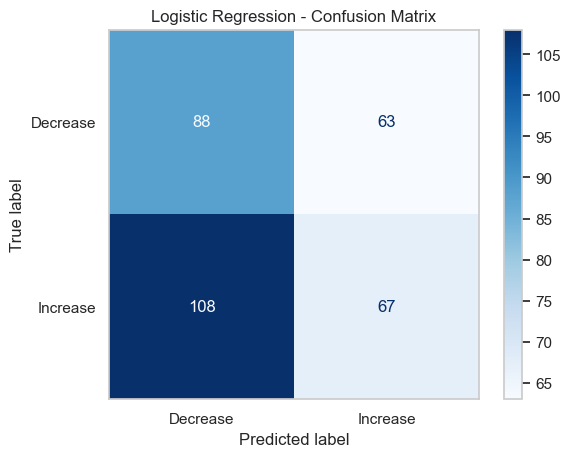

<Figure size 500x400 with 0 Axes>

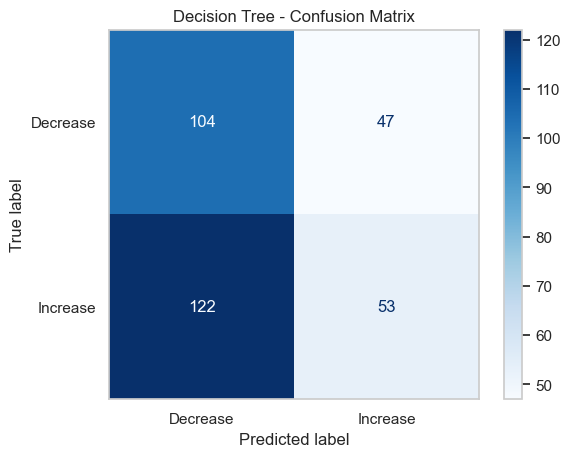

<Figure size 500x400 with 0 Axes>

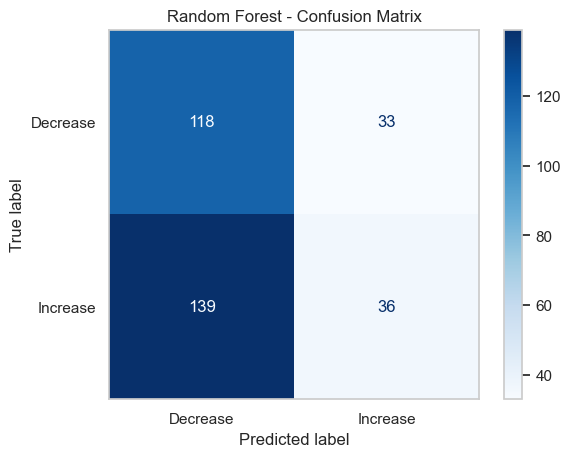

<Figure size 500x400 with 0 Axes>

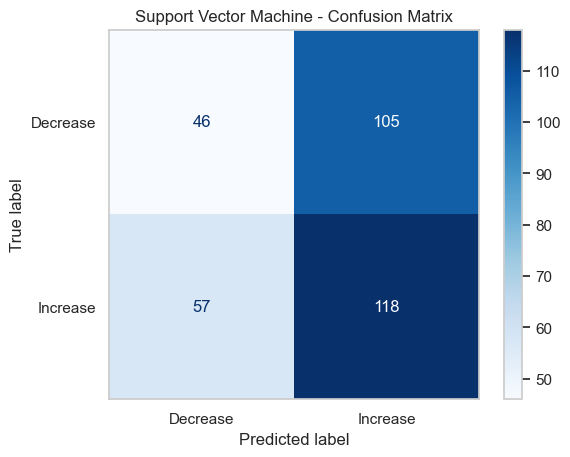

<Figure size 500x400 with 0 Axes>

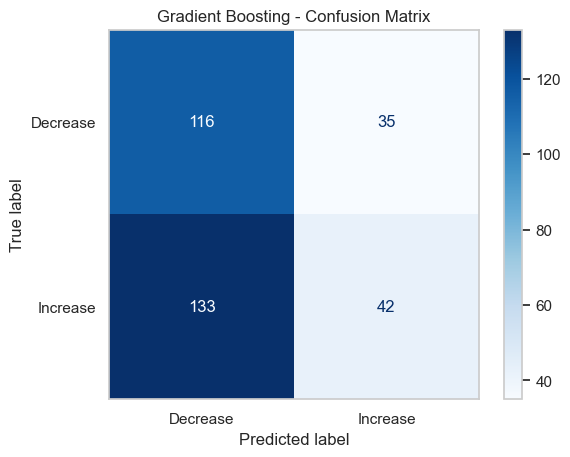

Model Evaluation Completed Successfully.


In [69]:
# Model Evaluation

# ----------------------------------------------------------
# Evaluate Models
# ----------------------------------------------------------

evaluation_results = []

for model_name in trained_models.keys():

    y_pred = predictions[model_name]
    y_prob = prediction_probabilities[model_name]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    if y_prob is not None:
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = np.nan

    evaluation_results.append({

        "Model": model_name,
        "Accuracy": round(accuracy,4),
        "Precision": round(precision,4),
        "Recall": round(recall,4),
        "F1-Score": round(f1,4),
        "ROC-AUC": round(roc_auc,4)

    })

# Performance Comparison Table

results_df = pd.DataFrame(evaluation_results)

print("Model Performance Comparison")

display(results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True))

# Classification Report

for model_name in trained_models.keys():

    print("="*70)
    print(f"{model_name} - Classification Report")
    print("="*70)

    print(classification_report(
        y_test,
        predictions[model_name]
    ))

# Confusion Matrix

for model_name in trained_models.keys():

    plt.figure(figsize=(5,4))

    cm = confusion_matrix(
        y_test,
        predictions[model_name]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Decrease","Increase"]
    )

    disp.plot(cmap="Blues", values_format='d')

    plt.title(f"{model_name} - Confusion Matrix")

    plt.grid(False)

    plt.show()

print("Model Evaluation Completed Successfully.")

Machine Learning Model Performance Comparison


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Support Vector Machine,0.5031,0.5291,0.6743,0.5930,0.5200
1,Gradient Boosting,0.4847,0.5455,0.2400,0.3333,0.5342
2,Decision Tree,0.4816,0.5300,0.3029,0.3855,0.4958
3,Logistic Regression,0.4755,0.5154,0.3829,0.4393,0.4737
4,Random Forest,0.4724,0.5217,0.2057,0.2951,0.5058


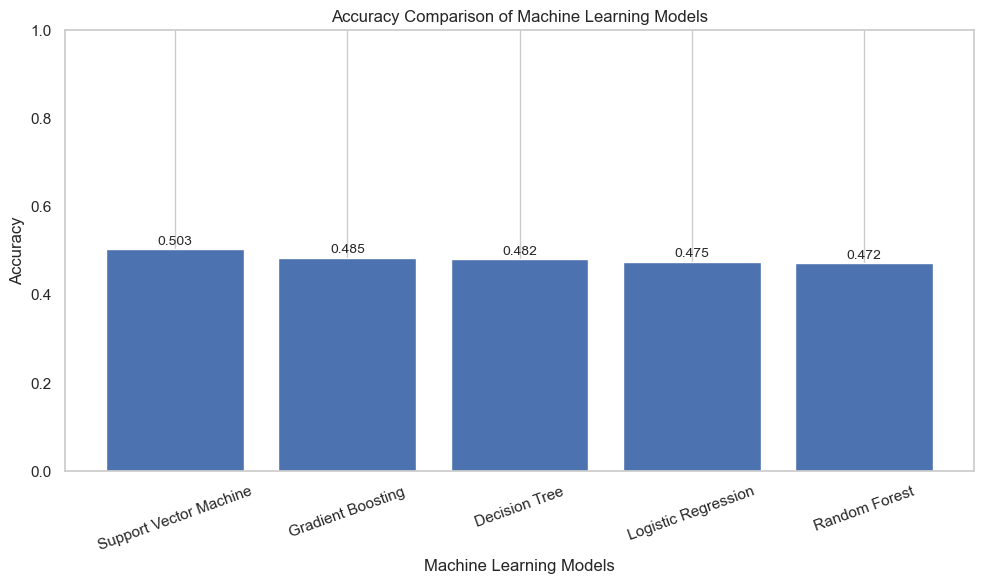

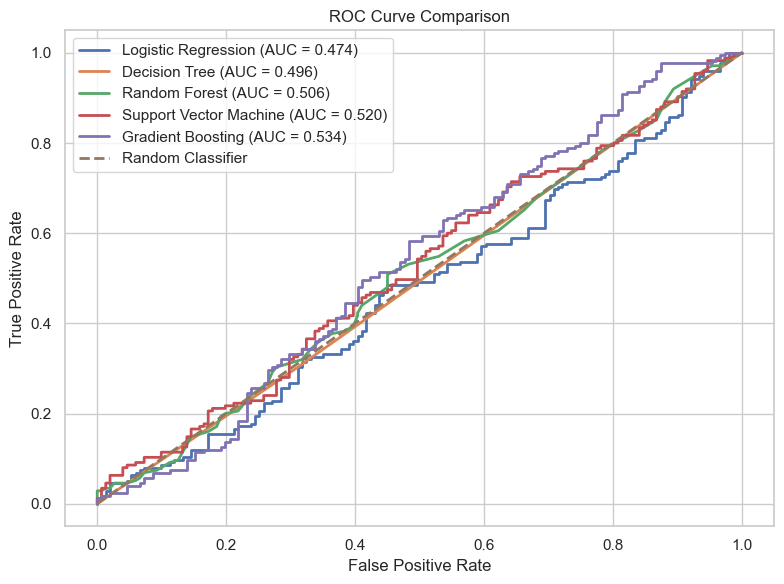


Best Performing Model
----------------------------------------
Model      : Support Vector Machine
Accuracy   : 0.5031
Precision  : 0.5291
Recall     : 0.6743
F1-Score   : 0.5930
ROC-AUC    : 0.5200


In [71]:
# Model Comparison

# Performance Comparison Table

comparison_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("Machine Learning Model Performance Comparison")

display(comparison_df)

# Accuracy Comparison Chart

plt.figure(figsize=(10,6))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

plt.ylim(0,1)

# Display values on bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        fontsize=10
    )

plt.xticks(rotation=20)

plt.grid(axis='y')

plt.tight_layout()

plt.show()

# ROC Curve Comparison

plt.figure(figsize=(8,6))

for model_name in trained_models.keys():

    if prediction_probabilities[model_name] is not None:

        fpr, tpr, _ = roc_curve(
            y_test,
            prediction_probabilities[model_name]
        )

        auc = roc_auc_score(
            y_test,
            prediction_probabilities[model_name]
        )

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{model_name} (AUC = {auc:.3f})"
        )

# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

# Best Performing Model

best_model = comparison_df.iloc[0]

print("\nBest Performing Model")
print("-"*40)

print(f"Model      : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Precision  : {best_model['Precision']:.4f}")
print(f"Recall     : {best_model['Recall']:.4f}")
print(f"F1-Score   : {best_model['F1-Score']:.4f}")
print(f"ROC-AUC    : {best_model['ROC-AUC']:.4f}")

Random Forest Feature Importance


,Feature,Importance
0,Daily_Return,0.0751
1,BB_Width,0.0645
2,RSI,0.0644
3,Momentum,0.0627
4,Rolling_Volatility,0.0610
5,Volume,0.0587
6,MACD_Histogram,0.0555
7,MACD,0.0538
8,MACD_Signal,0.0520
9,High,0.0454



Gradient Boosting Feature Importance


,Feature,Importance
0,BB_Width,0.1452
1,Daily_Return,0.1196
2,RSI,0.0966
3,MACD_Signal,0.0713
4,Momentum,0.0614
5,Low,0.0537
6,MACD_Histogram,0.0508
7,Volume,0.0483
8,Rolling_Volatility,0.0459
9,MACD,0.0450


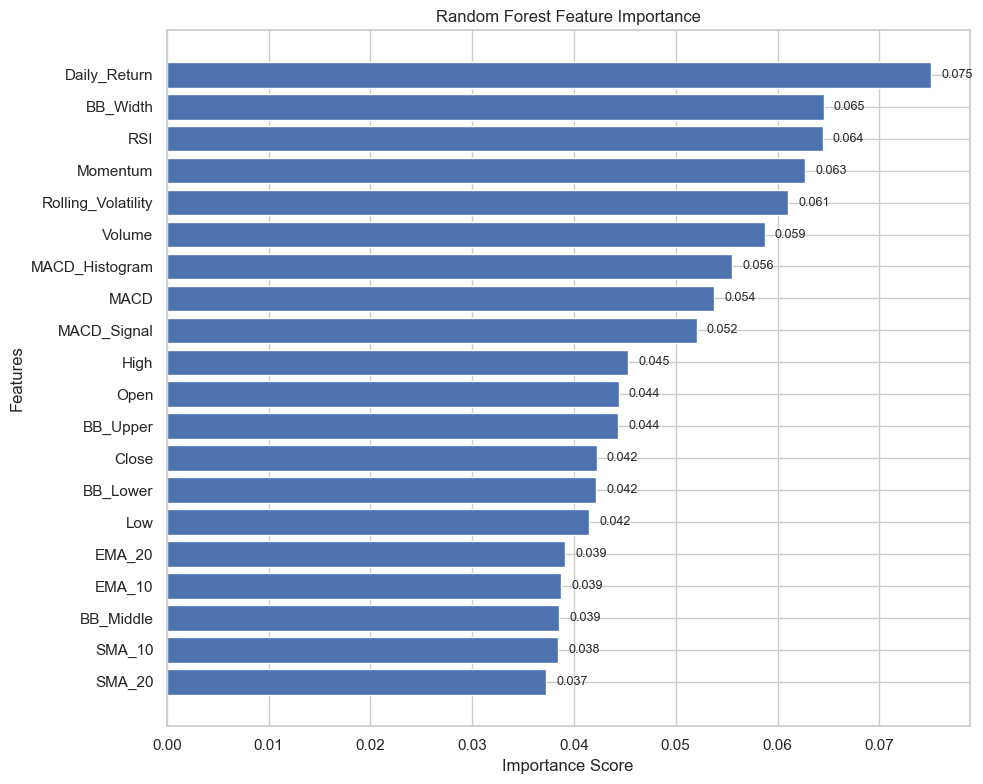

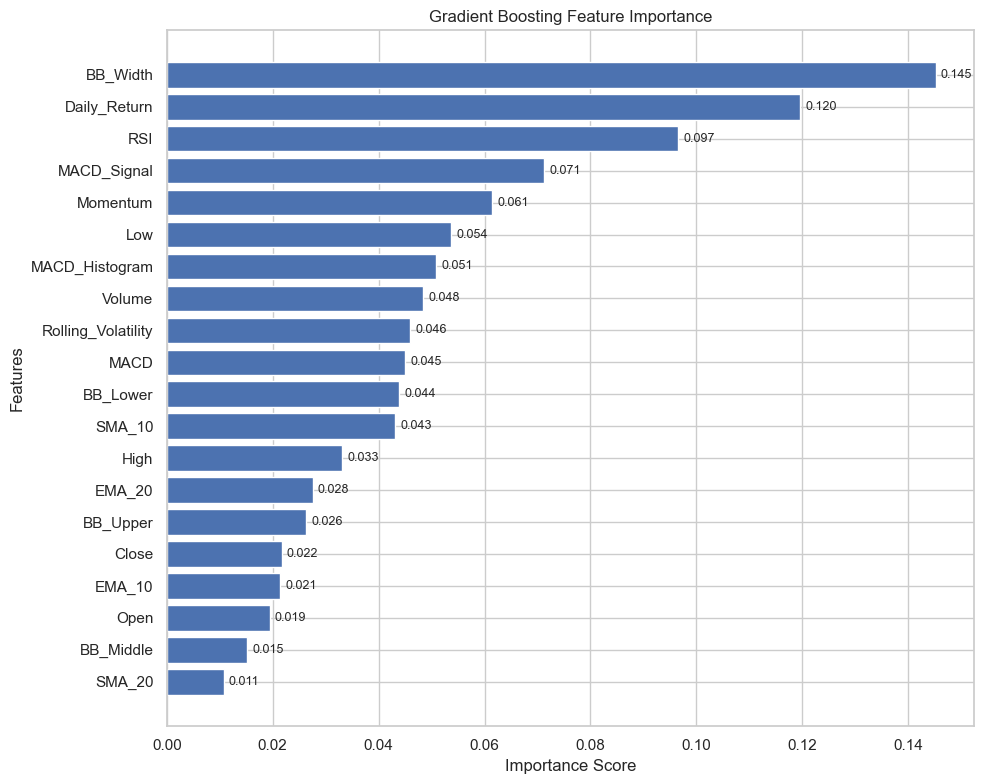


Overall Technical Indicator Ranking


,Feature,Random Forest,Gradient Boosting,Average Importance
0,BB_Width,0.0645,0.1452,0.1048
1,Daily_Return,0.0751,0.1196,0.0973
2,RSI,0.0644,0.0966,0.0805
3,Momentum,0.0627,0.0614,0.0620
4,MACD_Signal,0.0520,0.0713,0.0617
5,Volume,0.0587,0.0483,0.0535
6,Rolling_Volatility,0.0610,0.0459,0.0535
7,MACD_Histogram,0.0555,0.0508,0.0532
8,MACD,0.0538,0.0450,0.0494
9,Low,0.0415,0.0537,0.0476



Top 10 Most Important Features


,Feature,Random Forest,Gradient Boosting,Average Importance
0,BB_Width,0.0645,0.1452,0.1048
1,Daily_Return,0.0751,0.1196,0.0973
2,RSI,0.0644,0.0966,0.0805
3,Momentum,0.0627,0.0614,0.0620
4,MACD_Signal,0.0520,0.0713,0.0617
5,Volume,0.0587,0.0483,0.0535
6,Rolling_Volatility,0.0610,0.0459,0.0535
7,MACD_Histogram,0.0555,0.0508,0.0532
8,MACD,0.0538,0.0450,0.0494
9,Low,0.0415,0.0537,0.0476


In [73]:
# Feature Importance Analysis

# Retrieve trained models
rf_model = trained_models["Random Forest"]
gb_model = trained_models["Gradient Boosting"]

# Random Forest Feature Importance

rf_importance = pd.DataFrame({

    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_

})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Random Forest Feature Importance")

display(rf_importance)

# Gradient Boosting Feature Importance

gb_importance = pd.DataFrame({

    "Feature": X_train.columns,
    "Importance": gb_model.feature_importances_

})

gb_importance = gb_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("\nGradient Boosting Feature Importance")

display(gb_importance)

# Random Forest Feature Importance Chart

plt.figure(figsize=(10,8))

bars = plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 0.001,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# Gradient Boosting Feature Importance Chart

plt.figure(figsize=(10,8))

bars = plt.barh(
    gb_importance["Feature"],
    gb_importance["Importance"]
)

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 0.001,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# Combined Feature Ranking

combined_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Random Forest":
        rf_model.feature_importances_,

    "Gradient Boosting":
        gb_model.feature_importances_

})

combined_importance["Average Importance"] = (

    combined_importance["Random Forest"] +

    combined_importance["Gradient Boosting"]

) / 2

combined_importance = combined_importance.sort_values(
    by="Average Importance",
    ascending=False
).reset_index(drop=True)

print("\nOverall Technical Indicator Ranking")

display(combined_importance)

print("\nTop 10 Most Important Features")

display(combined_importance.head(10))

Best Model Selected: Support Vector Machine


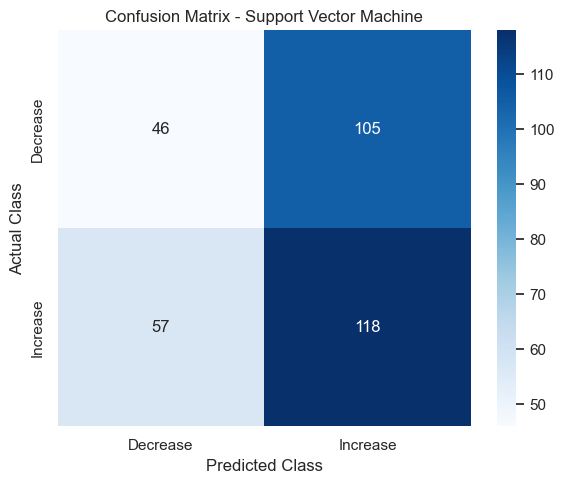

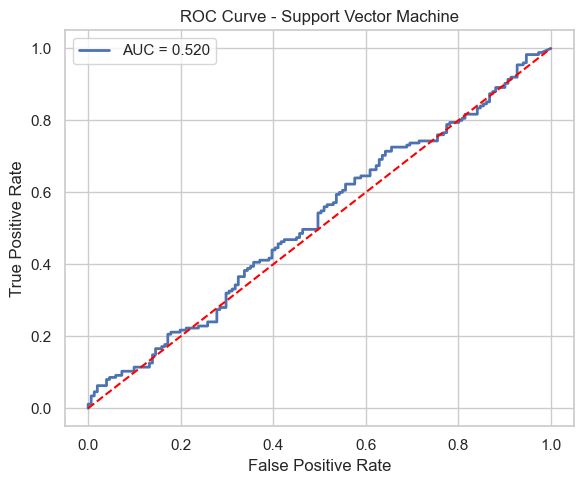

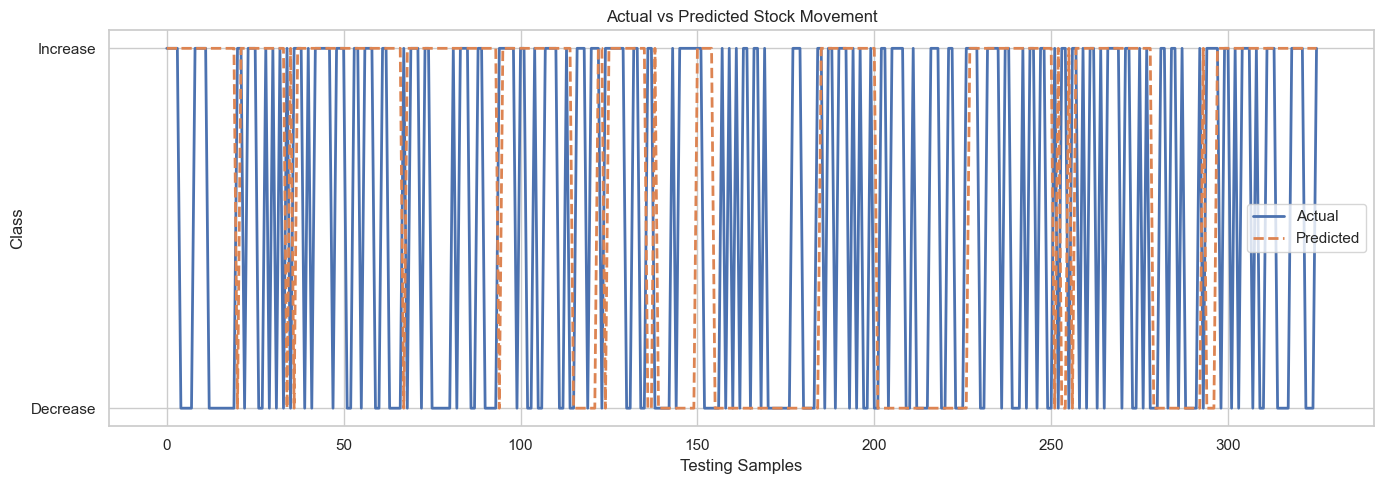

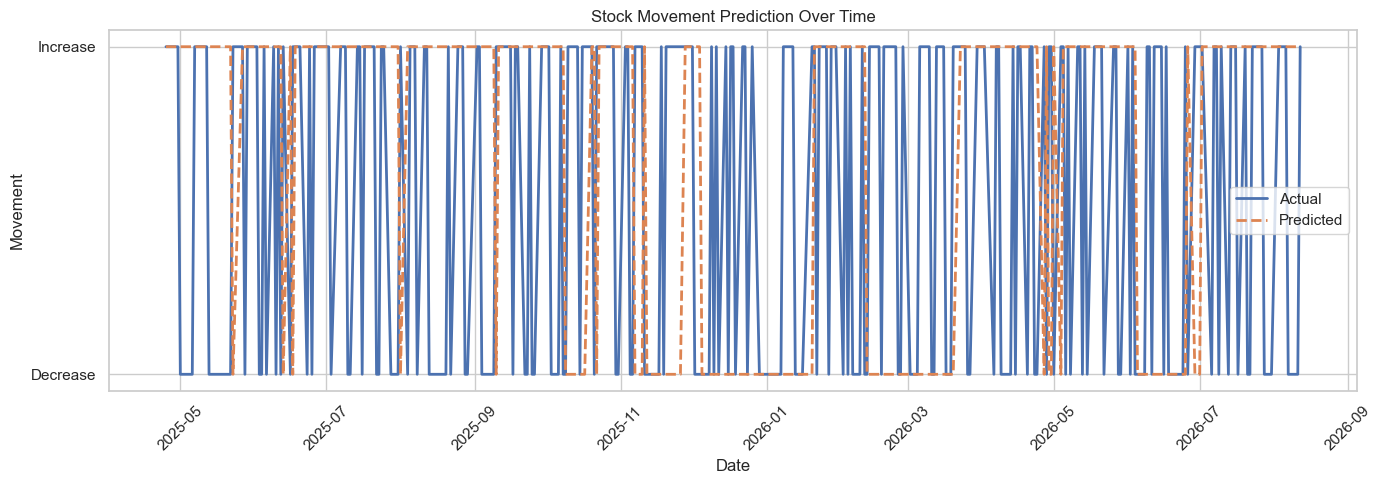


Prediction Visualization Completed Successfully.


In [75]:
# Prediction Visualization

# Best model (highest accuracy)
best_model_name = comparison_df.iloc[0]["Model"]

print(f"Best Model Selected: {best_model_name}")

best_predictions = predictions[best_model_name]
best_probabilities = prediction_probabilities[best_model_name]

# Confusion Matrix

plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, best_predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Decrease','Increase'],
    yticklabels=['Decrease','Increase']
)

plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.tight_layout()
plt.show()

# ROC Curve

fpr, tpr, _ = roc_curve(
    y_test,
    best_probabilities
)

auc = roc_auc_score(
    y_test,
    best_probabilities
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'AUC = {auc:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='red'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.show()

# Feature Importance Plot
# (Tree-based model only)

if best_model_name in ["Decision Tree", "Random Forest", "Gradient Boosting"]:

    importance = pd.DataFrame({

        "Feature": X_train.columns,
        "Importance": trained_models[best_model_name].feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    plt.figure(figsize=(10,8))

    bars = plt.barh(
        importance["Feature"],
        importance["Importance"]
    )

    plt.gca().invert_yaxis()

    for bar in bars:

        width = bar.get_width()

        plt.text(
            width + 0.001,
            bar.get_y() + bar.get_height()/2,
            f"{width:.3f}",
            va="center"
        )

    plt.title(f"{best_model_name} Feature Importance")
    plt.xlabel("Importance Score")

    plt.tight_layout()
    plt.show()

# Actual vs Predicted Results

comparison = pd.DataFrame({

    "Actual": y_test.values,
    "Predicted": best_predictions

})

comparison = comparison.reset_index(drop=True)

plt.figure(figsize=(14,5))

plt.plot(
    comparison.index,
    comparison["Actual"],
    label="Actual",
    linewidth=2
)

plt.plot(
    comparison.index,
    comparison["Predicted"],
    label="Predicted",
    linestyle='--',
    linewidth=2
)

plt.title("Actual vs Predicted Stock Movement")
plt.xlabel("Testing Samples")
plt.ylabel("Class")

plt.yticks([0,1],["Decrease","Increase"])

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.show()

# Stock Movement Prediction Graph

plot_df = pd.DataFrame({

    "Date": features_df.iloc[
        split_index:split_index+len(y_test)
    ]["Date"].values,

    "Actual": y_test.values,

    "Predicted": best_predictions

})

plt.figure(figsize=(14,5))

plt.plot(
    plot_df["Date"],
    plot_df["Actual"],
    label="Actual",
    linewidth=2
)

plt.plot(
    plot_df["Date"],
    plot_df["Predicted"],
    linestyle='--',
    label="Predicted",
    linewidth=2
)

plt.title("Stock Movement Prediction Over Time")
plt.xlabel("Date")
plt.ylabel("Movement")

plt.yticks([0,1],["Decrease","Increase"])

plt.xticks(rotation=45)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

print("\nPrediction Visualization Completed Successfully.")

In [77]:
# Hyperparameter Tuning Using GridSearchCV

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

# Dictionary to store tuned models
best_models = {}

print("Hyperparameter Tuning Started...\n")

Hyperparameter Tuning Started...



In [79]:
# Logistic Regression

lr_parameters = {

    'C': [0.001, 0.01, 0.1, 1, 10, 100],

    'solver': [
        'liblinear',
        'lbfgs'
    ],

    'penalty': [
        'l2'
    ],

    'max_iter': [
        500,
        1000,
        2000
    ]

}

lr_grid = GridSearchCV(

    LogisticRegression(random_state=42),

    lr_parameters,

    cv=tscv,

    scoring='accuracy',

    n_jobs=-1

)

lr_grid.fit(X_train_scaled, y_train)

best_models["Logistic Regression"] = lr_grid.best_estimator_

print("Logistic Regression Completed")
print(lr_grid.best_params_)
print()

Logistic Regression Completed
{'C': 0.001, 'max_iter': 500, 'penalty': 'l2', 'solver': 'liblinear'}



In [81]:
# Decision Tree

dt_parameters = {

    'criterion': [
        'gini',
        'entropy'
    ],

    'max_depth': [
        3,
        5,
        7,
        10,
        15,
        20,
        None
    ],

    'min_samples_split': [
        2,
        5,
        10,
        20
    ],

    'min_samples_leaf': [
        1,
        2,
        4,
        8
    ],

    'max_features': [
        None,
        'sqrt',
        'log2'
    ]

}

dt_grid = GridSearchCV(

    DecisionTreeClassifier(random_state=42),

    dt_parameters,

    cv=tscv,

    scoring='accuracy',

    n_jobs=-1

)

dt_grid.fit(X_train, y_train)

best_models["Decision Tree"] = dt_grid.best_estimator_

print("Decision Tree Completed")
print(dt_grid.best_params_)
print()

Decision Tree Completed
{'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5}



In [85]:
# Random Forest

rf_parameters = {

    'n_estimators': [
        100,
        200,
        300
    ],

    'max_depth': [
        10,
        20,
        30,
        None
    ],

    'min_samples_split': [
        2,
        5,
        10
    ],

    'min_samples_leaf': [
        1,
        2,
        4
    ],

    'max_features': [
        'sqrt',
        'log2'
    ],

    'bootstrap': [
        True,
        False
    ]

}

rf_grid = GridSearchCV(

    RandomForestClassifier(random_state=42),

    rf_parameters,

    cv=tscv,

    scoring='accuracy',

    n_jobs=-1

)

rf_grid.fit(X_train, y_train)

best_models["Random Forest"] = rf_grid.best_estimator_

print("Random Forest Completed")
print(rf_grid.best_params_)
print()

Random Forest Completed
{'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}



In [87]:
# Support Vector Machine

svm_parameters = {

    'C': [
        0.1,
        1,
        10,
        100
    ],

    'kernel': [
        'linear',
        'rbf'
    ],

    'gamma': [
        'scale',
        'auto',
        0.001,
        0.01,
        0.1
    ]

}

svm_grid = GridSearchCV(

    SVC(

        probability=True,

        random_state=42

    ),

    svm_parameters,

    cv=tscv,

    scoring='accuracy',

    n_jobs=-1

)

svm_grid.fit(X_train_scaled, y_train)

best_models["Support Vector Machine"] = svm_grid.best_estimator_

print("Support Vector Machine Completed")
print(svm_grid.best_params_)
print()

Support Vector Machine Completed
{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}



In [ ]:
# Gradient Boosting

gb_parameters = {

    'n_estimators': [
        100,
        200,
        300
    ],

    'learning_rate': [
        0.01,
        0.05,
        0.1,
        0.2
    ],

    'max_depth': [
        3,
        5,
        7
    ],

    'min_samples_split': [
        2,
        5,
        10
    ],

    'min_samples_leaf': [
        1,
        2,
        4
    ],

    'subsample': [
        0.8,
        1.0
    ]

}

gb_grid = GridSearchCV(

    GradientBoostingClassifier(random_state=42),

    gb_parameters,

    cv=tscv,

    scoring='accuracy',

    n_jobs=-1

)

gb_grid.fit(X_train, y_train)

best_models["Gradient Boosting"] = gb_grid.best_estimator_

print("Gradient Boosting Completed")
print(gb_grid.best_params_)
print()

In [ ]:
# Best Models

summary = pd.DataFrame({

    "Model": list(best_models.keys()),

    "Status": ["Optimized"] * len(best_models)

})

display(summary)

print("\nHyperparameter Tuning Completed Successfully.")

In [ ]:
# Evaluation of Optimized Machine Learning Models

# Prediction Using Optimized Models

optimized_predictions = {}
optimized_probabilities = {}

for model_name, model in best_models.items():

    if model_name in ["Logistic Regression", "Support Vector Machine"]:

        X_test_model = X_test_scaled

    else:

        X_test_model = X_test

    # Predict classes
    optimized_predictions[model_name] = model.predict(X_test_model)

    # Predict probabilities
    if hasattr(model, "predict_proba"):

        optimized_probabilities[model_name] = model.predict_proba(X_test_model)[:, 1]

    else:

        optimized_probabilities[model_name] = None

# Model Evaluation

evaluation_results = []

for model_name in best_models.keys():

    y_pred = optimized_predictions[model_name]
    y_prob = optimized_probabilities[model_name]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    if y_prob is not None:

        auc = roc_auc_score(y_test, y_prob)

    else:

        auc = np.nan

    evaluation_results.append({

        "Model": model_name,
        "Accuracy": round(accuracy,4),
        "Precision": round(precision,4),
        "Recall": round(recall,4),
        "F1-Score": round(f1,4),
        "ROC-AUC": round(auc,4)

    })

# Performance Comparison Table

results_df = pd.DataFrame(evaluation_results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("Optimized Model Performance Comparison")

display(results_df)

# Classification Reports

for model_name in best_models.keys():

    print("="*80)
    print(model_name)
    print("="*80)

    print(classification_report(

        y_test,

        optimized_predictions[model_name]

    ))

# Confusion Matrices

for model_name in best_models.keys():

    cm = confusion_matrix(

        y_test,

        optimized_predictions[model_name]

    )

    plt.figure(figsize=(6,5))

    disp = ConfusionMatrixDisplay(

        confusion_matrix=cm,

        display_labels=["Decrease","Increase"]

    )

    disp.plot(

        cmap="Blues",

        values_format="d"

    )

    plt.title(f"{model_name} - Confusion Matrix")

    plt.grid(False)

    plt.tight_layout()

    plt.show()

# ROC Curves

plt.figure(figsize=(8,6))

for model_name in best_models.keys():

    if optimized_probabilities[model_name] is not None:

        fpr, tpr, _ = roc_curve(

            y_test,

            optimized_probabilities[model_name]

        )

        auc = roc_auc_score(

            y_test,

            optimized_probabilities[model_name]

        )

        plt.plot(

            fpr,

            tpr,

            linewidth=2,

            label=f"{model_name} (AUC = {auc:.3f})"

        )

plt.plot(

    [0,1],

    [0,1],

    linestyle="--",

    color="black",

    linewidth=1.5,

    label="Random Classifier"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison (Optimized Models)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

print("\nOptimized Model Evaluation Completed Successfully.")

In [ ]:
# Best Model
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

if best_model_name in ["Decision Tree","Random Forest","Gradient Boosting"]:

    importance = pd.DataFrame({

        "Feature": X_train.columns,

        "Importance": best_models[best_model_name].feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    display(importance)

    plt.figure(figsize=(10,8))

    plt.barh(
        importance["Feature"],
        importance["Importance"]
    )

    plt.gca().invert_yaxis()

    plt.title(f"{best_model_name} Feature Importance")

    plt.xlabel("Importance Score")

    plt.tight_layout()

    plt.show()

In [ ]:
ranking = results_df.copy()

ranking.insert(

    0,

    "Rank",

    range(1,len(ranking)+1)

)

display(ranking)